# I. Data preparation

## Load CIFAR10 dataset

In [2]:
from torchvision import datasets, transforms
import torch

torch.manual_seed(42)

data_path = './../data'

# Define BATCH SIZE = 32
BATCH_SIZE = 128

# Define the data transformation
transform_train_1 = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(256),
    transforms.CenterCrop(224),
])

transform_train_2 = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(1)
])

transform_val = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor()
])


In [31]:
torch.manual_seed(42)
# Load the 2 datasets with different pre-processing methods
train_dataset_1 = datasets.CIFAR100(root=data_path, transform=transform_train_1, train=True, download=True)
train_dataset_2 = datasets.CIFAR100(root=data_path, transform=transform_train_2, train=True, download=True)
test_dataset = datasets.CIFAR100(root=data_path, transform=transform_val, train=False, download=True)

# # Concat train datasets
# train_dataset = torch.utils.data.ConcatDataset([train_dataset_1, train_dataset_2])

# # Train test split
# total_size = len(test_dataset)
# train_size = int(0.8 * total_size)
# test_size = total_size - train_size

# print(f"Total size of the dataset: {total_size}")
# print(f"Train size of the dataset: {train_size}")
# print(f"Test size of the dataset: {test_size}")

# generator = torch.Generator().manual_seed(42)
# train_indices, test_indices = torch.utils.data.random_split(
#     range(total_size), 
#     lengths=[train_size, test_size], 
#     generator=generator
# )

# # Create train, test splits from subset of loaded dataset
# train_dataset_split_1 = torch.utils.data.Subset(train_dataset_1, train_indices)
# train_dataset_split_2 = torch.utils.data.Subset(train_dataset_2, train_indices)
# test_dataset_split = torch.utils.data.Subset(test_dataset, test_indices)

# Concat 2 splitted train dataset
train_dataset_full = torch.utils.data.ConcatDataset([train_dataset_1, train_dataset_2])

# Load train and test data using DataLoader
train_dataloader = torch.utils.data.DataLoader(dataset=train_dataset_full, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=True)


c:\Users\z5719157\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [34]:
test_dataset.data[0].shape


(32, 32, 3)

In [36]:
images, labels = next(iter(train_dataloader))
print(images.shape)

torch.Size([128, 3, 224, 224])


In [6]:

imagenet_labels_map = test_dataset.classes
print(f"Number of classes: {len(imagenet_labels_map)}")

Number of classes: 100


In [28]:
import matplotlib.pyplot as plt
torch.manual_seed(42)

def plot_samples(dataset, nrows=3, ncols=3, figname="Train samples"):
    plt.figure(figsize=(3*nrows, 3*ncols))
    # Plot 
    for i in range(1,nrows*ncols+1):
        plt.subplot(nrows, ncols, i)
        random_idx = torch.randint(0, len(dataset), size=[1]).item()
        img = dataset[random_idx][0]
        img_whc = img.permute(1, 2, 0)
        label_num = dataset[random_idx][1]
        plt.imshow(img_whc)
        plt.title(imagenet_labels_map[label_num], fontsize=10)
        
    

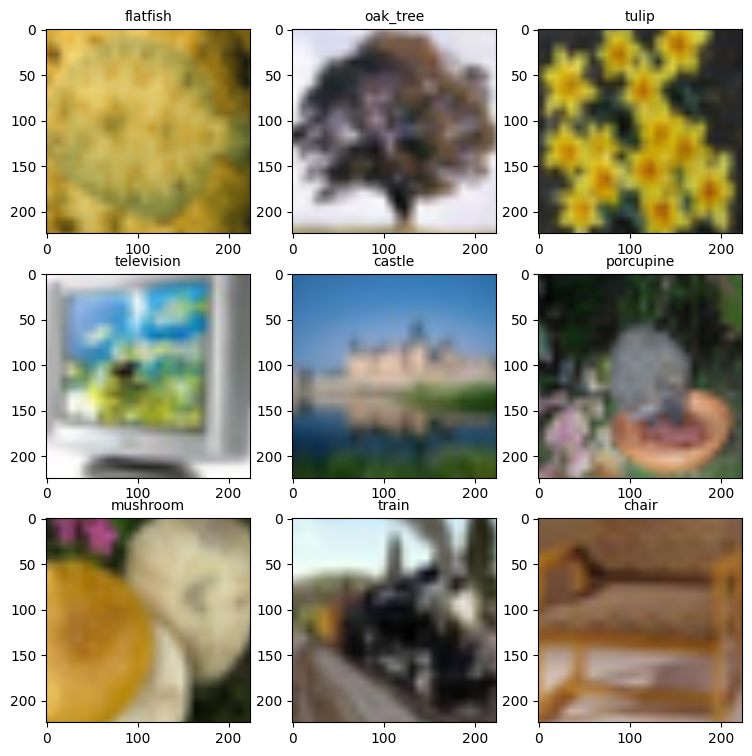

In [29]:
# Plot samples from train dataset
plot_samples(train_dataset_full, figname="Train samples visualization")

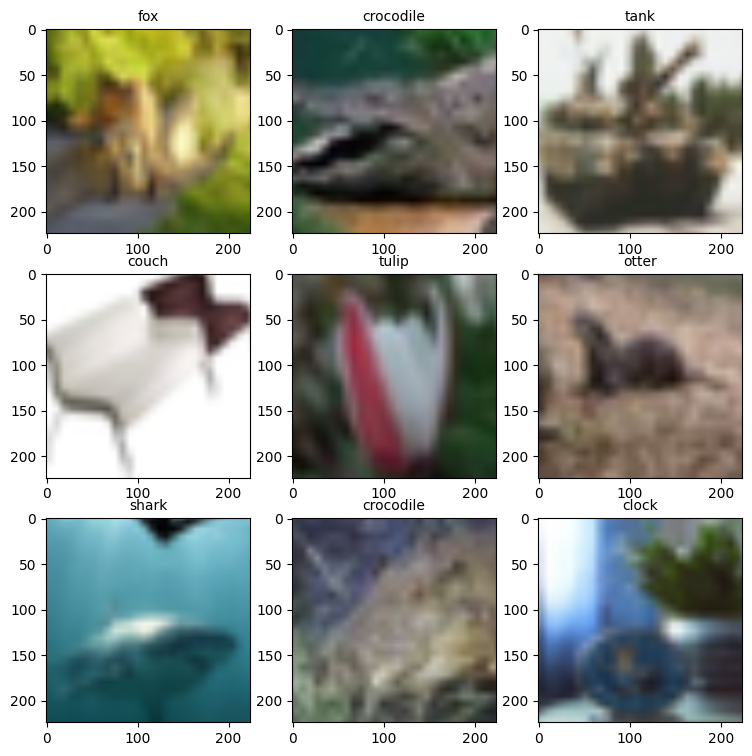

In [9]:
# Plot samples for test dataset
plot_samples(test_dataset, figname="Test samples visualization")

# Build AlexNet model from scratch


In [10]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# TODO: Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device


2.12.0+cu126


'cuda'

## Custom Normalization

In [11]:
import torch
from torch import nn
import math

class ResponseNormalization(nn.Module):
    def __init__(self, k=2, n=5, alpha=1e-4, beta=0.75):
        super().__init__()
        self.k = k
        self.n = n
        self.alpha = alpha
        self.beta = beta
    
    def forward(self, x:torch.Tensor):
        '''
        x: A tensor of shape (N, C, H, W)
        '''
        tensor_shape = list(x.size())
        N = tensor_shape[0]
        z = torch.zeros(tensor_shape)
        for i in range(tensor_shape[1]):
            z[:, i, :, :] = x[:, i, :, :] / torch.pow((self.k + self.alpha * torch.sum(torch.pow(x[:, int(max(0, i - self.n/2)) : int(min(N-1, i+self.n/2)), :, :], 2), dim=1)), self.beta)            
        return z

In [12]:
# Test reponse normalize function
torch.manual_seed(42)
X = torch.rand([1, 10, 3, 3])
normalization = ResponseNormalization()
X_norm = normalization(X)
print('Randomized tensor: ', X[0, 0, :, :])
print('Normalized tensor: ', X_norm[0, 0, :, :])

Randomized tensor:  tensor([[0.8823, 0.9150, 0.3829],
        [0.9593, 0.3904, 0.6009],
        [0.2566, 0.7936, 0.9408]])
Normalized tensor:  tensor([[0.5246, 0.5441, 0.2277],
        [0.5704, 0.2322, 0.3573],
        [0.1526, 0.4719, 0.5594]])


$$O = \dfrac{I-K+2P}{S} + 1$$

## AlexNet

In [13]:
        
class AlexNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Layer 1: start from 224 x 224
        self.layer1A = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=48, kernel_size=11, stride=4, padding=2), # 55 x 55 
            nn.ReLU(),
            nn.LocalResponseNorm(size=5, alpha=0.0001, beta=0.75, k=2.0),
            nn.MaxPool2d(kernel_size=3, stride=2) # 27 x 27
        )

        self.layer1B = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=48, kernel_size=11, stride=4, padding=2), # 55 x 55
            nn.ReLU(),
            nn.LocalResponseNorm(size=5, alpha=0.0001, beta=0.75, k=2.0),
            nn.MaxPool2d(kernel_size=3, stride=2) # 27 x 27
        )

        # Layer 2: start from 27 x 27
        self.layer2A = nn.Sequential(
            nn.Conv2d(in_channels=48, out_channels=128, kernel_size=5, stride=1, padding=2), # 27 x 27
            nn.ReLU(),
            nn.LocalResponseNorm(size=5, alpha=0.0001, beta=0.75, k=2.0),
            nn.MaxPool2d(kernel_size=3, stride=2) # 13 x 13
        )

        self.layer2B = nn.Sequential(
            nn.Conv2d(in_channels=48, out_channels=128, kernel_size=5, stride=1, padding=2), # 27 x 27
            nn.ReLU(),
            nn.LocalResponseNorm(size=5, alpha=0.0001, beta=0.75, k=2.0),
            nn.MaxPool2d(kernel_size=3, stride=2) # 13 x 13
        )

        # Layer 3, 4, 5: start from 13 x 13
        self.layer3A = nn.Sequential(
            nn.Conv2d(in_channels=128*2, out_channels=192, kernel_size=3, padding=1), # 13 x 13
            nn.ReLU()
        )

        self.layer3B = nn.Sequential(
            nn.Conv2d(in_channels=128*2, out_channels=192, kernel_size=3, padding=1), # 13 x 13
            nn.ReLU()
        )
        
        self.layer4A = nn.Sequential(
            nn.Conv2d(in_channels=192, out_channels=192, kernel_size=3, padding=1), # 13 x 13
            nn.ReLU()
        )

        self.layer4B = nn.Sequential(
            nn.Conv2d(in_channels=192, out_channels=192, kernel_size=3, padding=1), # 13 x 13
            nn.ReLU()
        )

        self.layer5A = nn.Sequential(
            nn.Conv2d(in_channels=192, out_channels=128, kernel_size=3, padding=1), # 13 x 13
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2) # 6 x 6
        )

        self.layer5B = nn.Sequential(
            nn.Conv2d(in_channels=192, out_channels=128, kernel_size=3, padding=1), # 13 x 13
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2) # 6 x 6
        )

        # Layer 6, 7, 8: start from 128 x 2 x 6 x 6
        self.dense_layer = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.5),
            nn.Linear(in_features=128*2*6*6, out_features=4096),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(in_features=4096, out_features=4096),
            nn.ReLU(),
            nn.Linear(in_features=4096, out_features=1000)
        )

    def forward(self, x):
        # Feedforward from layer 1 to layer 2
        a = self.layer2A(self.layer1A(x))
        b = self.layer2B(self.layer1B(x))

        # Merge two results
        c = torch.concatenate((a, b), dim=1)

        # Feedforward from layer 3 to layer 5 
        a = self.layer5A(self.layer4A(self.layer3A(c)))
        b = self.layer5B(self.layer4B(self.layer3B(c)))

        # Merge two results
        c = torch.concatenate((a, b), dim=1)

        # Feedforward dense layer
        z = self.dense_layer(c)
        return z



In [14]:
model = AlexNet()
model

AlexNet(
  (layer1A): Sequential(
    (0): Conv2d(3, 48, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU()
    (2): LocalResponseNorm(5, alpha=0.0001, beta=0.75, k=2.0)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer1B): Sequential(
    (0): Conv2d(3, 48, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU()
    (2): LocalResponseNorm(5, alpha=0.0001, beta=0.75, k=2.0)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2A): Sequential(
    (0): Conv2d(48, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): LocalResponseNorm(5, alpha=0.0001, beta=0.75, k=2.0)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2B): Sequential(
    (0): Conv2d(48, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): LocalResponseNorm(5, alpha=0.0001, beta=0.75, k=2.0)
    (3): Ma

## Prepare Loss function and Optimizer


In [15]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=0.0005)
# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    """Calculates accuracy between truth labels and predictions.

    Args:
        y_true (torch.Tensor): Truth labels for predictions.
        y_pred (torch.Tensor): Predictions to be compared to predictions.

    Returns:
        [torch.float]: Accuracy value between y_true and y_pred, e.g. 78.45
    """
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

In [18]:
def train_step(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module, optimizer: torch.optim.Optimizer, accuracy_fn, device):
    model.train()
    model.to(device)
    train_loss = 0
    train_acc = 0
    for batch, (X, y) in enumerate(dataloader):
        X = X.to(device)
        y = y.to(device)
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        train_acc += accuracy_fn(y_true = y, y_pred=y_pred.argmax(dim=1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if (batch % 50 == 0):
            print(f"Training batch {batch} / {len(dataloader)}")
    train_loss /= len(dataloader)
    train_acc /= len(dataloader)
    print(f"Train loss: {train_loss} | Train acc: {train_acc}")
    
def test_step(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module, optimizer: torch.optim.Optimizer, accuracy_fn, device="cpu"):
    model.to(device)
    model.eval()
    test_loss = 0
    test_acc = 0
    with torch.inference_mode():
        for batch, (X, y) in enumerate(dataloader):
            X = X.to(device)
            y = y.to(device)
            test_pred = model(X)
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y, test_pred.argmax(dim=1))
            if (batch % 200 == 0):
                print(f"Testing batch {batch} / {len(dataloader)}")
        test_loss /= len(dataloader)
        test_acc /= len(dataloader)
    print(f"Test loss: {test_loss} | Test acc: {test_acc}")



In [19]:
# Training loop
epochs = 100
print(device)
for epoch in range(epochs): 
    print(f"Epoch [{epoch}/{epochs}]=========")
    train_step(
        model=model,
        dataloader=train_dataloader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn,
        device='cuda'
    )
    test_step(
        model=model,
        dataloader=test_dataloader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn,
        device='cuda'
    )


    

cuda
Epoch [0/100]=========
Training batch 0 / 782
Training batch 50 / 782
Training batch 100 / 782
Training batch 150 / 782
Training batch 200 / 782
Training batch 250 / 782
Training batch 300 / 782
Training batch 350 / 782
Training batch 400 / 782
Training batch 450 / 782
Training batch 500 / 782
Training batch 550 / 782
Training batch 600 / 782
Training batch 650 / 782
Training batch 700 / 782
Training batch 750 / 782
Train loss: 4.008100459642727 | Train acc: 7.096187659846548
Testing batch 0 / 79
Test loss: 3.907608985900879 | Test acc: 8.69264240506329
Epoch [1/100]=========
Training batch 0 / 782
Training batch 50 / 782
Training batch 100 / 782
Training batch 150 / 782
Training batch 200 / 782
Training batch 250 / 782
Training batch 300 / 782
Training batch 350 / 782
Training batch 400 / 782
Training batch 450 / 782
Training batch 500 / 782
Training batch 550 / 782
Training batch 600 / 782
Training batch 650 / 782
Training batch 700 / 782
Training batch 750 / 782
Train loss: 3.8

In [39]:
test_dataset[0][0].shape

torch.Size([3, 224, 224])

In [ ]:
torch.manual_seed(42)

def plot_predictions(dataset, nrows, ncols, model, figname):
    plt.figure(figsize=(4*nrows, 4*ncols))
    # Plot 
    with torch.inference_mode():
        for i in range(1,nrows*ncols+1):
            
            plt.subplot(nrows, ncols, i)
            
            model.to('cpu')
            model.eval()

            random_idx = torch.randint(0, len(dataset), size=[1]).item()
            img = dataset[random_idx][0]
            
            # Ground truth
            img_whc = img.permute(1, 2, 0)
            label_num = dataset[random_idx][1]
            
            # Predict value
            pred_label = torch.softmax(model(img.unsqueeze(dim=0)), dim=1).argmax(dim=1).item()
            

            plt.imshow(img_whc)
            plt.title(f"Ground truth: {imagenet_labels_map[label_num]} | Prediction: {imagenet_labels_map[pred_label]}", fontsize=10)
        
    

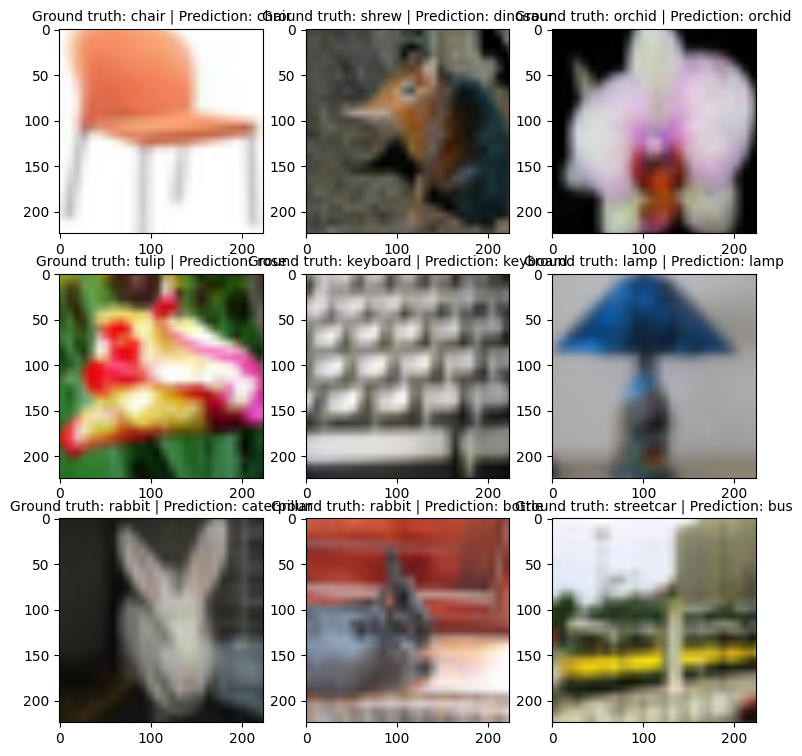

In [49]:
plot_predictions(test_dataset, 3, 3, model, "Predictions")

49
mountain


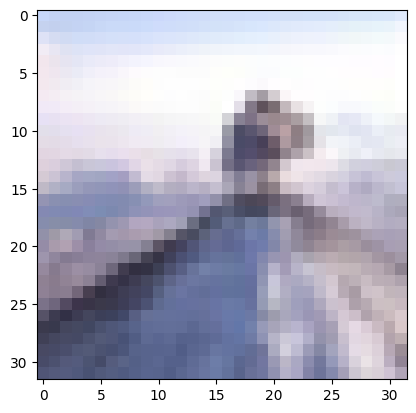

In [ ]:
# Visualize some result 

with torch.inference_mode():
    model.to('cpu')
    y_pred = torch.softmax(model(test_dataset[0][0].unsqueeze(dim=0)), dim=1).argmax(dim=1).item()
    print(y_pred)
    print(imagenet_labels_map[y_pred])
plt.imshow(test_dataset.data[0])